---
# Stage 3 – Data Preprocessing & Cleaning <a id='stage3'></a>

## 3.1 Preprocessing Strategy

The UCI HAR dataset is already windowed and reasonably clean. However, we must apply proper preprocessing for each model pathway:

| Step | Classical ML (SVM/RF) | Deep Learning (LSTM) |
|------|-----------------------|----------------------|
| Input | 561-dim feature vector | Raw signals (128, 9) |
| Normalization | StandardScaler per feature | Per-channel min-max or z-score |
| Label encoding | y as integers (1–6) | y one-hot encoded |
| Duplicate removal | ✓ | ✓ |
| Missing value handling | Fill/drop (none found) | Fill/drop (none found) |
| Feature deduplication | Remove duplicate columns | N/A |

In [3]:
# ─── Setup: Load UCI HAR data required for Stage 3 ───────────────────────────
import os
import numpy as np
import pandas as pd

DATA_ROOT = 'UCI HAR Dataset'
TRAIN_PATH = os.path.join(DATA_ROOT, 'train')
TEST_PATH = os.path.join(DATA_ROOT, 'test')

ACTIVITY_MAP = {
    1: 'Walking',
    2: 'Walking Upstairs',
    3: 'Walking Downstairs',
    4: 'Sitting',
    5: 'Standing',
    6: 'Laying'
}

def load_har_features(data_root=DATA_ROOT):
    X_train = pd.read_csv(
        os.path.join(data_root, 'train', 'X_train.txt'),
        sep='\\s+', header=None
    ).values
    X_test = pd.read_csv(
        os.path.join(data_root, 'test', 'X_test.txt'),
        sep='\\s+', header=None
    ).values

    y_train = pd.read_csv(
        os.path.join(data_root, 'train', 'y_train.txt'),
        header=None
    ).values.ravel()
    y_test = pd.read_csv(
        os.path.join(data_root, 'test', 'y_test.txt'),
        header=None
    ).values.ravel()

    feature_names = pd.read_csv(
        os.path.join(data_root, 'features.txt'),
        sep='\\s+', header=None
    )[1].tolist()

    return X_train, X_test, y_train, y_test, feature_names

def load_raw_signals(split_path, signal_names):
    inertial_path = os.path.join(split_path, 'Inertial Signals')
    split_tag = 'train' if 'train' in split_path else 'test'
    channels = []
    for name in signal_names:
        fpath = os.path.join(inertial_path, f'{name}_{split_tag}.txt')
        channels.append(pd.read_csv(fpath, sep='\\s+', header=None).values)
    return np.stack(channels, axis=-1)

SIGNAL_NAMES = [
    'body_acc_x', 'body_acc_y', 'body_acc_z',
    'body_gyro_x', 'body_gyro_y', 'body_gyro_z',
    'total_acc_x', 'total_acc_y', 'total_acc_z'
 ]

X_train, X_test, y_train, y_test, feature_names = load_har_features(DATA_ROOT)
X_raw_train = load_raw_signals(TRAIN_PATH, SIGNAL_NAMES)
X_raw_test = load_raw_signals(TEST_PATH, SIGNAL_NAMES)

print('Setup complete for preprocessing notebook.')
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'X_raw_train: {X_raw_train.shape}, X_raw_test: {X_raw_test.shape}')

Setup complete for preprocessing notebook.
X_train: (7352, 561), X_test: (2947, 561)
X_raw_train: (7352, 128, 9), X_raw_test: (2947, 128, 9)


In [16]:
# ─── Step 3.1: Remove Duplicate Feature Columns ──────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_train_feat = pd.DataFrame(X_train, columns=feature_names)
df_test_feat  = pd.DataFrame(X_test,  columns=feature_names)

# Identify duplicate column names (UCI HAR has some duplicates)
dup_cols = df_train_feat.columns[df_train_feat.columns.duplicated()].unique().tolist()
print(f"Duplicate column names found: {len(dup_cols)}")
if dup_cols:
    print(f"  → {dup_cols[:10]} ...")  # show first 10

# Keep first occurrence of each duplicated name
df_train_clean = df_train_feat.loc[:, ~df_train_feat.columns.duplicated()]
df_test_clean  = df_test_feat.loc[:,  ~df_test_feat.columns.duplicated()]

print(f"\nFeature count before dedup : {df_train_feat.shape[1]}")
print(f"Feature count after  dedup : {df_train_clean.shape[1]}")

Duplicate column names found: 42
  → ['fBodyAcc-bandsEnergy()-1,8', 'fBodyAcc-bandsEnergy()-9,16', 'fBodyAcc-bandsEnergy()-17,24', 'fBodyAcc-bandsEnergy()-25,32', 'fBodyAcc-bandsEnergy()-33,40', 'fBodyAcc-bandsEnergy()-41,48', 'fBodyAcc-bandsEnergy()-49,56', 'fBodyAcc-bandsEnergy()-57,64', 'fBodyAcc-bandsEnergy()-1,16', 'fBodyAcc-bandsEnergy()-17,32'] ...

Feature count before dedup : 561
Feature count after  dedup : 477


In [5]:
# ─── Step 3.2: Remove Duplicate Rows ─────────────────────────────────────────
df_train_clean['_label'] = y_train
df_test_clean['_label']  = y_test

n_before_train = len(df_train_clean)
n_before_test  = len(df_test_clean)

df_train_clean = df_train_clean.drop_duplicates()
df_test_clean  = df_test_clean.drop_duplicates()

y_train_clean  = df_train_clean['_label'].values
y_test_clean   = df_test_clean['_label'].values

df_train_clean = df_train_clean.drop(columns=['_label'])
df_test_clean  = df_test_clean.drop(columns=['_label'])

print(f"Train rows before: {n_before_train} → after: {len(df_train_clean)} "
      f"(removed: {n_before_train - len(df_train_clean)})")
print(f"Test  rows before: {n_before_test}  → after: {len(df_test_clean)} "
      f"(removed: {n_before_test - len(df_test_clean)})")

Train rows before: 7352 → after: 7352 (removed: 0)
Test  rows before: 2947  → after: 2947 (removed: 0)


In [6]:
# ─── Step 3.3: StandardScaler for Classical ML ───────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler_ml = StandardScaler()

X_train_scaled = scaler_ml.fit_transform(df_train_clean.values)
X_test_scaled  = scaler_ml.transform(df_test_clean.values)

print("=== StandardScaler Applied ===")
print(f"Train → mean={X_train_scaled.mean():.4f}, std={X_train_scaled.std():.4f}")
print(f"Test  → mean={X_test_scaled.mean():.4f},  std={X_test_scaled.std():.4f}")
print(f"\nX_train_scaled shape : {X_train_scaled.shape}")
print(f"X_test_scaled  shape : {X_test_scaled.shape}")

=== StandardScaler Applied ===
Train → mean=0.0000, std=1.0000
Test  → mean=-0.0058,  std=0.9417

X_train_scaled shape : (7352, 477)
X_test_scaled  shape : (2947, 477)


In [7]:
# ─── Step 3.4: Label Encoding ─────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(list(ACTIVITY_MAP.keys()))

# For classical ML: zero-indexed labels (0–5)
y_train_enc = le.transform(y_train_clean)
y_test_enc  = le.transform(y_test_clean)

print("=== Label Encoding ===")
print(f"Original labels  : {np.unique(y_train_clean)}")
print(f"Encoded labels   : {np.unique(y_train_enc)}")
print("Mapping:")
for orig, enc in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {orig} ({ACTIVITY_MAP[orig]}) → {enc}")

=== Label Encoding ===
Original labels  : [1 2 3 4 5 6]
Encoded labels   : [0 1 2 3 4 5]
Mapping:
  1 (Walking) → 0
  2 (Walking Upstairs) → 1
  3 (Walking Downstairs) → 2
  4 (Sitting) → 3
  5 (Standing) → 4
  6 (Laying) → 5


In [8]:
# ─── Step 3.5: Normalize Raw Signals for LSTM ────────────────────────────────
# Z-score normalize each channel independently across the training set
# Shape: (N, 128, 9)

# Compute per-channel mean & std from training data
channel_mean = X_raw_train.mean(axis=(0, 1), keepdims=True)   # (1, 1, 9)
channel_std  = X_raw_train.std(axis=(0, 1),  keepdims=True)   # (1, 1, 9)

# Avoid division by zero
channel_std = np.where(channel_std == 0, 1.0, channel_std)

X_raw_train_norm = (X_raw_train - channel_mean) / channel_std
X_raw_test_norm  = (X_raw_test  - channel_mean) / channel_std  # apply TRAIN stats

print("=== Raw Signal Normalization ===")
print(f"Per-channel means (train): {channel_mean.flatten().round(4)}")
print(f"Per-channel stds  (train): {channel_std.flatten().round(4)}")
print(f"\nX_raw_train_norm → mean={X_raw_train_norm.mean():.4f}, std={X_raw_train_norm.std():.4f}")
print(f"X_raw_test_norm  → mean={X_raw_test_norm.mean():.4f},  std={X_raw_test_norm.std():.4f}")

=== Raw Signal Normalization ===
Per-channel means (train): [-6.000e-04 -3.000e-04 -3.000e-04  5.000e-04 -8.000e-04  1.000e-04
  8.047e-01  2.880e-02  8.650e-02]
Per-channel stds  (train): [0.1948 0.1224 0.1069 0.4068 0.3819 0.2557 0.4141 0.391  0.3578]

X_raw_train_norm → mean=-0.0000, std=1.0000
X_raw_test_norm  → mean=-0.0072,  std=0.9534


In [9]:
# ─── Step 3.6: One-Hot Encode Labels for LSTM ────────────────────────────────
from tensorflow.keras.utils import to_categorical

n_classes = len(ACTIVITY_MAP)

y_train_ohe = to_categorical(y_train_enc, num_classes=n_classes)
y_test_ohe  = to_categorical(y_test_enc,  num_classes=n_classes)

print("=== One-Hot Encoding ===")
print(f"y_train_ohe shape : {y_train_ohe.shape}")
print(f"y_test_ohe  shape : {y_test_ohe.shape}")
print(f"Sample (first row): {y_train_ohe[0]}  → class {np.argmax(y_train_ohe[0])} ({ACTIVITY_MAP[y_train_clean[0]]})")

=== One-Hot Encoding ===
y_train_ohe shape : (7352, 6)
y_test_ohe  shape : (2947, 6)
Sample (first row): [0. 0. 0. 0. 1. 0.]  → class 4 (Standing)


In [10]:
# ─── Step 3.7: Additional Feature Engineering (Time + Frequency Domain) ──────
from scipy import stats
from scipy.fft import fft

def extract_time_features(window):
    """Extract time-domain statistics from a (128, 9) window."""
    feats = []
    for ch in range(window.shape[1]):
        sig = window[:, ch]
        feats += [
            sig.mean(),
            sig.std(),
            np.abs(sig).mean(),       # mean absolute value
            sig.max() - sig.min(),    # range
            stats.skew(sig),
            stats.kurtosis(sig),
            np.percentile(sig, 25),
            np.percentile(sig, 75),
            np.sqrt(np.mean(sig**2)), # RMS
            np.sum(sig**2),           # signal energy
        ]
    return feats

def extract_freq_features(window, fs=50):
    """Extract frequency-domain features from a (128, 9) window."""
    feats = []
    freqs = np.fft.rfftfreq(window.shape[0], d=1.0/fs)
    for ch in range(window.shape[1]):
        sig = window[:, ch]
        fft_mag = np.abs(np.fft.rfft(sig))
        power = fft_mag ** 2
        total_power = power.sum() + 1e-10
        feats += [
            fft_mag.mean(),
            fft_mag.std(),
            fft_mag.max(),
            freqs[np.argmax(fft_mag)],              # dominant frequency
            np.sum(power * freqs) / total_power,     # spectral centroid
            np.sum(power[:len(power)//2]) / total_power,  # low-freq energy ratio
        ]
    return feats

def extract_all_features(X_raw_norm):
    """Apply time + frequency feature extraction to every window."""
    all_feats = []
    for i in range(len(X_raw_norm)):
        w = X_raw_norm[i]    # (128, 9)
        tf = extract_time_features(w)
        ff = extract_freq_features(w)
        all_feats.append(tf + ff)
    return np.array(all_feats)

print("Extracting handcrafted time + frequency features from raw signals...")
print("(This may take 1–2 minutes)")

X_hand_train = extract_all_features(X_raw_train_norm)
X_hand_test  = extract_all_features(X_raw_test_norm)

n_time_feats = 9 * 10    # 9 channels × 10 time stats
n_freq_feats = 9 * 6     # 9 channels × 6 freq stats
print(f"\nHandcrafted features per window:")
print(f"  Time-domain : {n_time_feats}")
print(f"  Freq-domain : {n_freq_feats}")
print(f"  Total       : {n_time_feats + n_freq_feats}")
print(f"\nX_hand_train shape : {X_hand_train.shape}")
print(f"X_hand_test  shape : {X_hand_test.shape}")

Extracting handcrafted time + frequency features from raw signals...
(This may take 1–2 minutes)

Handcrafted features per window:
  Time-domain : 90
  Freq-domain : 54
  Total       : 144

X_hand_train shape : (7352, 144)
X_hand_test  shape : (2947, 144)


In [11]:
# ─── Step 3.8: Scale Handcrafted Features ────────────────────────────────────
scaler_hand = StandardScaler()
X_hand_train_sc = scaler_hand.fit_transform(X_hand_train)
X_hand_test_sc  = scaler_hand.transform(X_hand_test)

print(f"X_hand_train_sc → mean={X_hand_train_sc.mean():.4f}, std={X_hand_train_sc.std():.4f}")
print(f"X_hand_test_sc  → mean={X_hand_test_sc.mean():.4f},  std={X_hand_test_sc.std():.4f}")

X_hand_train_sc → mean=0.0000, std=1.0000
X_hand_test_sc  → mean=-0.0128,  std=0.9800


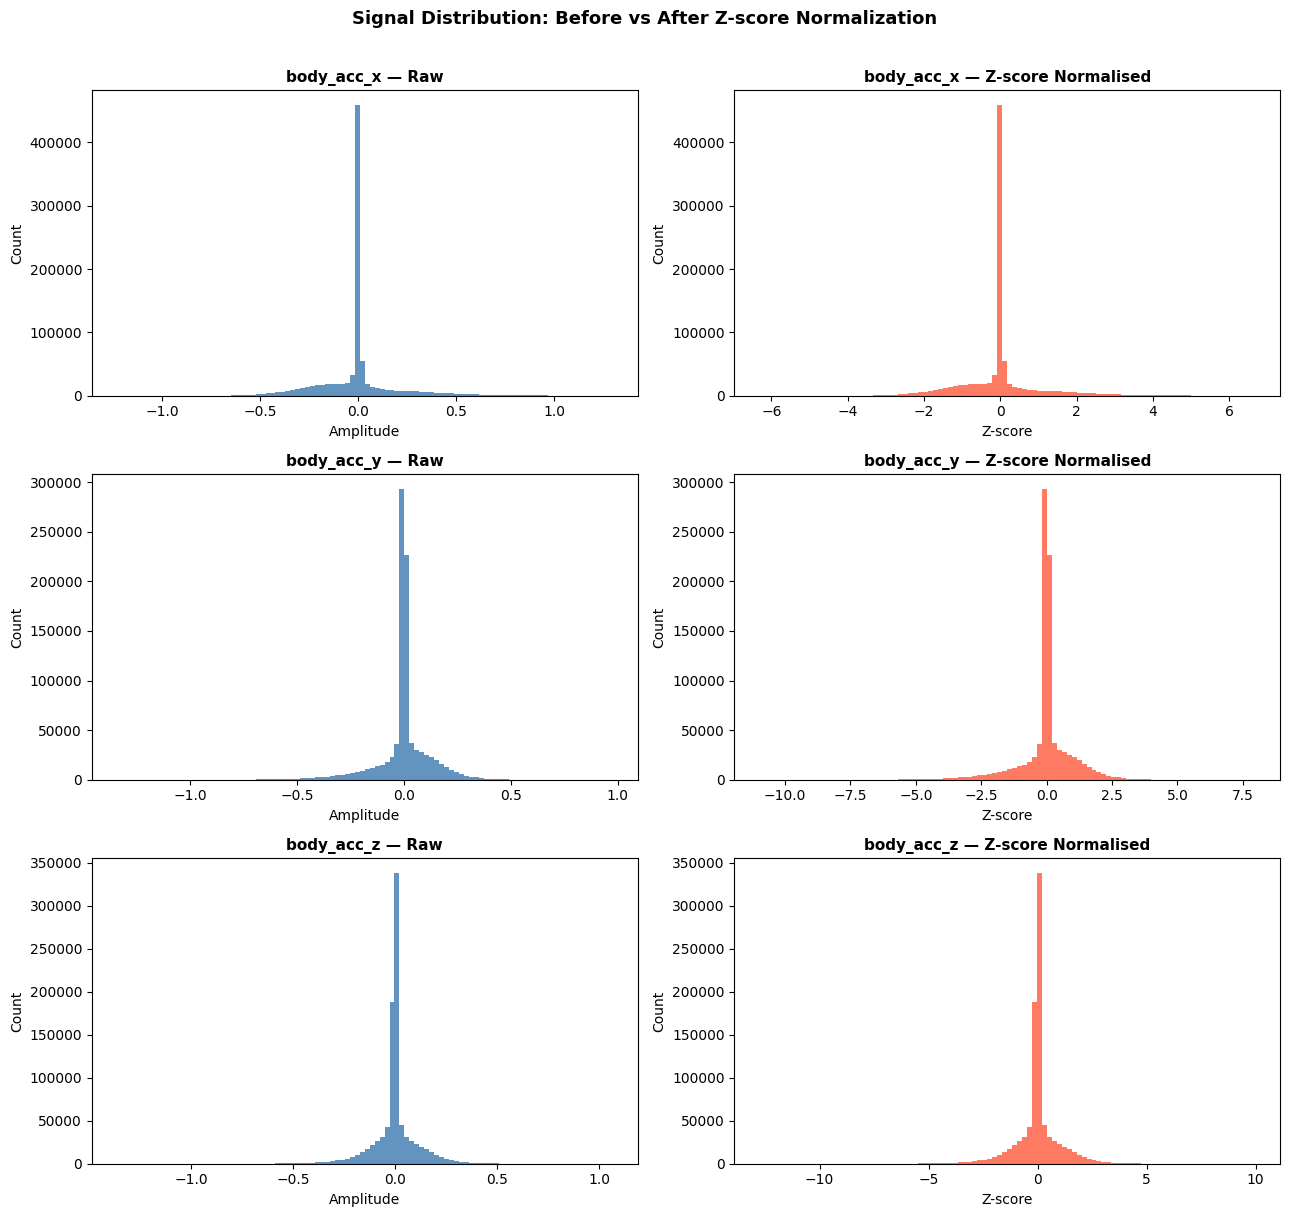

Saved: stage3_normalization_comparison.png


In [ ]:
# ─── Step 3.9: Visualise Before / After Normalization ─────────────────────────
# Show 3 channels (body_acc_x/y/z) — 2 columns per channel (raw | normalised)

channels_to_plot = [0, 1, 2]   # body_acc_x, body_acc_y, body_acc_z
ch_labels        = ['body_acc_x', 'body_acc_y', 'body_acc_z']

fig, axes = plt.subplots(len(channels_to_plot), 2,
                         figsize=(13, 4 * len(channels_to_plot)))

for row, (ch_idx, ch_name) in enumerate(zip(channels_to_plot, ch_labels)):
    raw_vals  = X_raw_train[:, :, ch_idx].flatten()
    norm_vals = X_raw_train_norm[:, :, ch_idx].flatten()

    axes[row, 0].hist(raw_vals,  bins=100, color='steelblue',
                      alpha=0.85, edgecolor='none')
    axes[row, 0].set_title(f'{ch_name} — Raw',        fontsize=11, fontweight='bold')
    axes[row, 0].set_xlabel('Amplitude')
    axes[row, 0].set_ylabel('Count')

    axes[row, 1].hist(norm_vals, bins=100, color='tomato',
                      alpha=0.85, edgecolor='none')
    axes[row, 1].set_title(f'{ch_name} — Z-score Normalised', fontsize=11, fontweight='bold')
    axes[row, 1].set_xlabel('Z-score')
    axes[row, 1].set_ylabel('Count')

fig.suptitle('Signal Distribution: Before vs After Z-score Normalization',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/stage3_normalization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/stage3_normalization_comparison.png")

In [13]:
# ─── Step 3.10: Low-Variance Feature Filtering ────────────────────────────
from sklearn.feature_selection import VarianceThreshold

# threshold=0.01 removes features with near-zero variance after scaling.
# This eliminates constant or near-constant columns that add no signal.
vt = VarianceThreshold(threshold=0.01)
X_train_vt = vt.fit_transform(X_train_scaled)
X_test_vt  = vt.transform(X_test_scaled)

n_removed = X_train_scaled.shape[1] - X_train_vt.shape[1]
kept_mask  = vt.get_support()

print(f"VarianceThreshold (threshold=0.01)")
print(f"  Features before : {X_train_scaled.shape[1]}")
print(f"  Features removed: {n_removed}")
print(f"  Features kept   : {X_train_vt.shape[1]}")

# Show the top 5 removed feature names so we know what was dropped
if n_removed > 0:
    removed_names = [feature_names[i] for i, keep in enumerate(kept_mask) if not keep]
    print(f"\n  Sample removed  : {removed_names[:5]}")
X_train_vt = vt.fit_transform(X_train_scaled)
X_test_vt  = vt.transform(X_test_scaled)

n_removed = X_train_scaled.shape[1] - X_train_vt.shape[1]
print(f"VarianceThreshold: removed {n_removed} zero-variance features.")
print(f"Features remaining: {X_train_vt.shape[1]}")

VarianceThreshold (threshold=0.01)
  Features before : 477
  Features removed: 0
  Features kept   : 477
VarianceThreshold: removed 0 zero-variance features.
Features remaining: 477


In [20]:
# ─── Stage 3 Summary: Preprocessed Objects Ready for Modelling ───────────────
print('=== PREPROCESSING COMPLETE ===')

print('\nClassical ML (SVM / Random Forest)')
print(f'X_train_vt      : {X_train_vt.shape}  (filtered UCI features)')
print(f'X_test_vt       : {X_test_vt.shape}')
print(f'X_hand_train_sc : {X_hand_train_sc.shape}  (handcrafted features)')
print(f'X_hand_test_sc  : {X_hand_test_sc.shape}')
print(f'y_train_enc     : {y_train_enc.shape}  (integer labels 0-5)')
print(f'y_test_enc      : {y_test_enc.shape}')

print('\nLSTM (Deep Learning)')
print(f'X_raw_train_norm: {X_raw_train_norm.shape}  (normalized sequences)')
print(f'X_raw_test_norm : {X_raw_test_norm.shape}')
print(f'y_train_ohe     : {y_train_ohe.shape}  (one-hot labels)')
print(f'y_test_ohe      : {y_test_ohe.shape}')

=== PREPROCESSING COMPLETE ===

Classical ML (SVM / Random Forest)
X_train_vt      : (7352, 477)  (filtered UCI features)
X_test_vt       : (2947, 477)
X_hand_train_sc : (7352, 144)  (handcrafted features)
X_hand_test_sc  : (2947, 144)
y_train_enc     : (7352,)  (integer labels 0-5)
y_test_enc      : (2947,)

LSTM (Deep Learning)
X_raw_train_norm: (7352, 128, 9)  (normalized sequences)
X_raw_test_norm : (2947, 128, 9)
y_train_ohe     : (7352, 6)  (one-hot labels)
y_test_ohe      : (2947, 6)


In [18]:
# ─── Save Preprocessed Arrays to Disk ────────────────────────────────────────
import joblib

os.makedirs('preprocessed', exist_ok=True)

# Classical ML arrays
np.save('preprocessed/X_train_vt.npy',       X_train_vt)
np.save('preprocessed/X_test_vt.npy',        X_test_vt)
np.save('preprocessed/X_hand_train_sc.npy',  X_hand_train_sc)
np.save('preprocessed/X_hand_test_sc.npy',   X_hand_test_sc)
np.save('preprocessed/y_train_enc.npy',      y_train_enc)
np.save('preprocessed/y_test_enc.npy',       y_test_enc)

# LSTM arrays
np.save('preprocessed/X_raw_train_norm.npy', X_raw_train_norm)
np.save('preprocessed/X_raw_test_norm.npy',  X_raw_test_norm)
np.save('preprocessed/y_train_ohe.npy',      y_train_ohe)
np.save('preprocessed/y_test_ohe.npy',       y_test_ohe)

# Scalers and encoder
joblib.dump(scaler_ml,   'preprocessed/scaler_ml.pkl')
joblib.dump(scaler_hand, 'preprocessed/scaler_hand.pkl')
joblib.dump(vt,          'preprocessed/variance_threshold.pkl')
joblib.dump(le,          'preprocessed/label_encoder.pkl')

print("All preprocessed arrays and scalers saved to ./preprocessed/")
for f in sorted(os.listdir('preprocessed')):
    size_kb = os.path.getsize(f'preprocessed/{f}') / 1024
    print(f"  {f:<35} {size_kb:>8.1f} KB")

All preprocessed arrays and scalers saved to ./preprocessed/
  X_hand_test_sc.npy                    3315.5 KB
  X_hand_train_sc.npy                   8271.1 KB
  X_raw_test_norm.npy                  26523.1 KB
  X_raw_train_norm.npy                 66168.1 KB
  X_test_vt.npy                        10982.3 KB
  X_train_vt.npy                       27397.8 KB
  label_encoder.pkl                        0.4 KB
  scaler_hand.pkl                          3.9 KB
  scaler_ml.pkl                           11.7 KB
  variance_threshold.pkl                   4.1 KB
  y_test_enc.npy                          23.1 KB
  y_test_ohe.npy                         138.3 KB
  y_train_enc.npy                         57.6 KB
  y_train_ohe.npy                        344.8 KB
